# Feature Engineering 

# Load the Data

In [6]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np

diabetes=load_diabetes()
df=pd.DataFrame(diabetes.data,columns=diabetes.feature_names)

df['target']=diabetes.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


# Polynomial and interaction Features (The Force Multiplier)
--> In medicine, variables rarely act alone. BMI is important, but BMI multiplied by blood pressure(bp) might reveal a much strong signal of diabetes progression.

In [7]:
df['bmi_bp_interaction']=df['bmi']*df['bp']

df['serum_ratio']=df['s1']/(df['s2']+1e-6)

# Non-Linear Transformation (The Lens Shift)
--> Some patterns are not straight lines. If a relationship is curved, a standard model might miss it . We use Powers and Logs to "straighten" the relationship for the model.

In [8]:
df['bmi_squared']=df['bmi']**2
df['age_squared']=df['age']**2

In [12]:

#Creating High Risk  flags  based on distribution
# If a value is in the top 10%, we flag it as Extreme.

bmi_threshold=df['bmi'].quantile(0.9)
df['is_high_bmi']=(df['bmi']>bmi_threshold).astype(int)

# Automated Feature Selection 

Now we have created many new features, but adding too many features can cause "Overfitting". We must now use statistical test to keep only the best one.

In [11]:
from sklearn.feature_selection import SelectKBest, f_regression

X=df.drop('target',axis=1)
y=df['target']


selector=SelectKBest(score_func=f_regression,k=10)
X_new=selector.fit_transform(X,y)

selected_features=X.columns[selector.get_support()]
print(f"Top 10 Features:{list(selected_features)}")

Top 10 Features:['age', 'bmi', 'bp', 's1', 's3', 's4', 's5', 's6', 'bmi_squared', 'is_high_bmi']


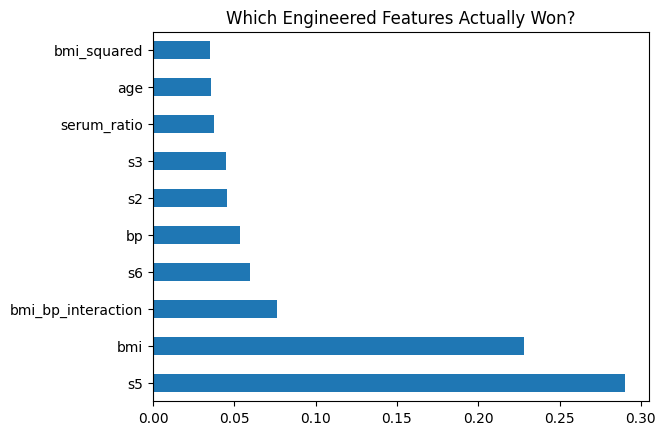

In [13]:
# Using a Random Forest to see what the new features actually did
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

model = RandomForestRegressor().fit(X, y)
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Which Engineered Features Actually Won?")
plt.show()